<div style="
background: linear-gradient(135deg, #fce4ec, #e8f5e9);
padding:40px;
border-radius:20px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 12px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1800px;
">

<h1 style="color:#AD1457; font-size:42px;">
📈 Sistema de Predicción de Ventas
</h1>

<h3 style="color:#8e7cc3;">
Series Temporales con ARIMA
</h3>

<p style="color:#666; font-size:18px;">
Análisis exploratorio • Modelado temporal • Predicción futura
</p>

<hr style="margin:25px 0;">

<p style="color:#777;">
Machine Learning · Forecasting · Time Series Analysis
</p>

</div>

Sistema de predicción de ventas
Queremos establecer el almacén de nuestra empresa en otra localización y necesitamos estimar el ritmo de las ventas, que desde la creación de la empresa ha ido en aumento, para los próximos meses, a fin de proveer el espacio que necesitaremos.

Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre sales.csv. Puedes cargarlos en el código directamente desde el siguiente enlace:

https://breathecode.herokuapp.com/asset/internal-link?id=2546&pa th=sales.csv
O descargarlo y añadirlo a mano en tu repositorio.

Paso 2: Construye y analiza la serie temporal
Construye la estructura de datos válida para la serie temporal, grafícala y, a continuación, analízala y responde a las siguientes preguntas:

- ¿Cuál es el tensor de la serie temporal?
- ¿Cuál es la tendencia?
- ¿Es estacionaria?
- ¿Existe variabilidad o presencia de ruido?

Nota: Un tensor en una serie temporal es la unidad de tiempo mínima para la cual hay datos. Puede ser cada segundo, minuto, hora, día, semana, mes...

Paso 3: Entrena un ARIMA
Utiliza los datos de entrenamiento para encontrar la mejor parametrización de tu modelo ARIMA.

Paso 4: Predice con el conjunto de test
Ahora utiliza el modelo entrenado con el conjunto de prueba y compara los puntos con los reales. Mide el rendimiento de la serie temporal.

Paso 5: Guarda el modelo
Almacena el modelo en la carpeta correspondiente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

import joblib

<div style="
background: linear-gradient(135deg,#fff3e0,#e3f2fd);
padding:25px;
border-radius:15px;
text-align:center;
margin:20px auto;
max-width:1000px;
border:1px solid #e0e0e0;
">

<h2 style="color:#ef6c00;">
📊 Exploración de Datos (EDA)
</h2>

<p style="color:#666;">
Carga del dataset, limpieza y análisis inicial de las ventas
</p>

</div>

In [2]:
df = pd.read_csv("../data/raw/sales.csv")

In [3]:
df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    str    
 1   sales   366 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.8 KB


In [5]:
df.describe()

,sales
count,366.000000
mean,524.963968
std,275.089698
min,53.803211
25%,290.186822
50%,520.699468
75%,763.289263
max,1000.482785


In [6]:
df.isnull().sum()

date     0
sales    0
dtype: int64

<div style="
background: linear-gradient(135deg,#ede7f6,#e0f2f1);
padding:25px;
border-radius:15px;
text-align:center;
margin:20px auto;
max-width:1000px;
border:1px solid #e0e0e0;
">

<h2 style="color:#5e35b1;">
⏳ Construcción y Análisis de la Serie Temporal
</h2>

<p style="color:#666;">
Tensor, tendencia, estacionariedad y variabilidad
</p>

</div>

In [7]:
df_ts = df.copy()

In [8]:
df_ts["date"] = pd.to_datetime(df_ts["date"])

In [9]:
df_ts["date"] = df_ts["date"].dt.floor("D")

In [10]:
df_ts = df_ts.set_index("date")

In [11]:
df_ts = df_ts.sort_index()

In [12]:
df_ts.head()

,sales
date,
2022-09-03,55.292157
2022-09-04,53.803211
2022-09-05,58.141693
2022-09-06,64.530899
2022-09-07,66.013633


In [13]:
df_ts.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 366 entries, 2022-09-03 to 2023-09-03
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sales   366 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB


In [14]:
df_ts.describe()

,sales
count,366.000000
mean,524.963968
std,275.089698
min,53.803211
25%,290.186822
50%,520.699468
75%,763.289263
max,1000.482785


### Tensor

In [15]:
df_ts.index.inferred_freq

'D'

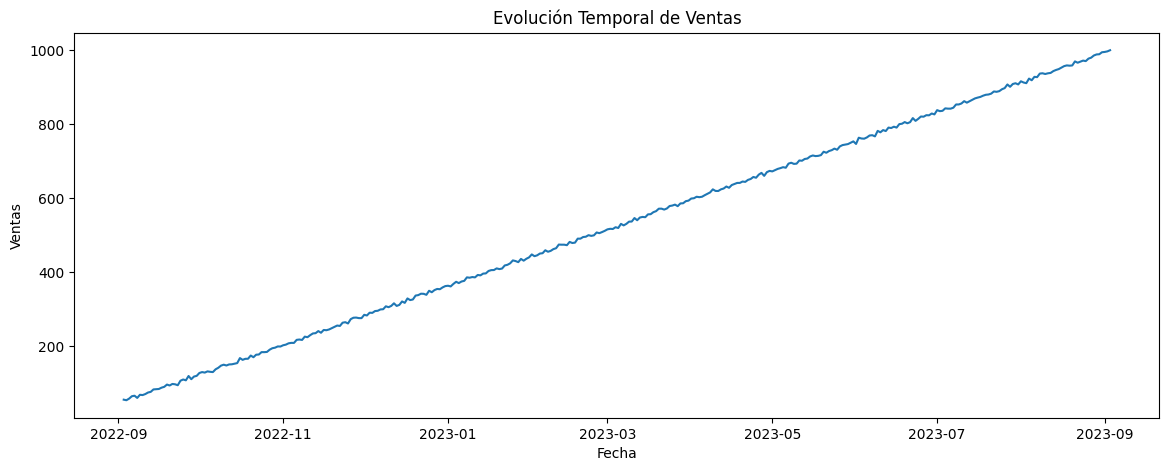

In [16]:
plt.figure(figsize=(14,5))
plt.plot(df_ts["sales"])
plt.title("Evolución Temporal de Ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()

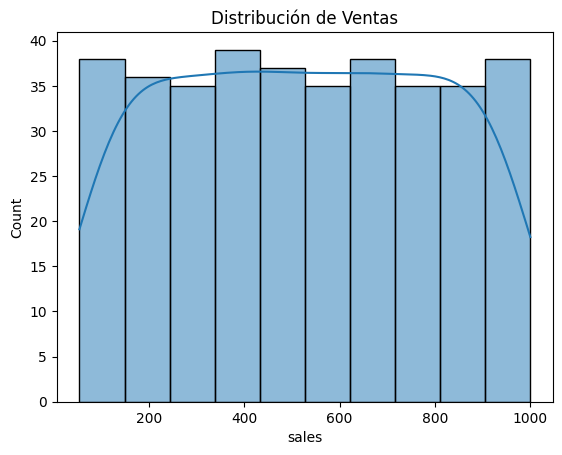

In [17]:
sns.histplot(df_ts["sales"], kde=True)
plt.title("Distribución de Ventas")
plt.show()

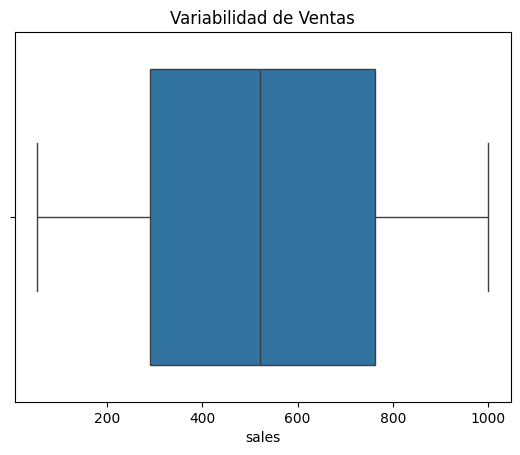

In [18]:
sns.boxplot(x=df_ts["sales"])
plt.title("Variabilidad de Ventas")
plt.show()

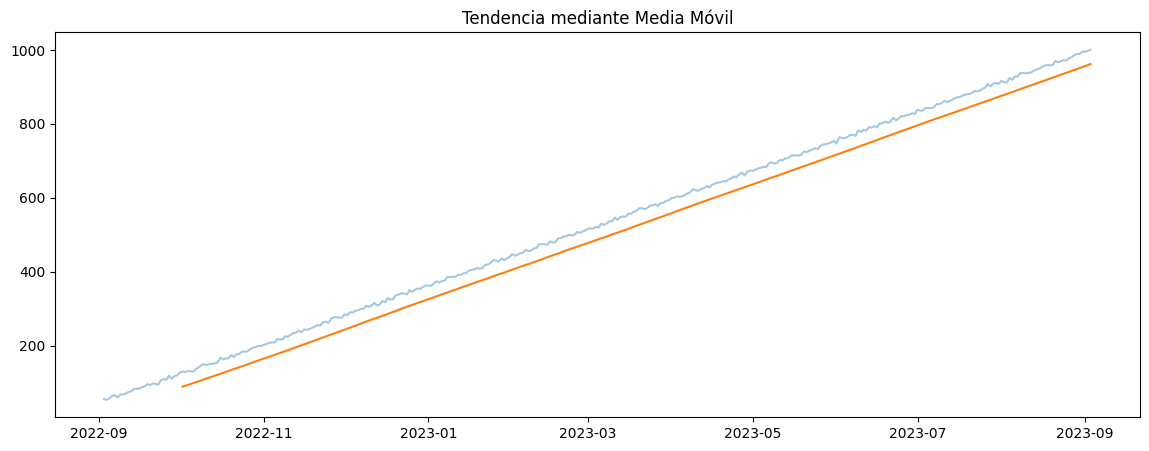

In [19]:
df_ts["rolling_mean"] = df_ts["sales"].rolling(30).mean()

plt.figure(figsize=(14,5))
plt.plot(df_ts["sales"], alpha=0.4)
plt.plot(df_ts["rolling_mean"])
plt.title("Tendencia mediante Media Móvil")
plt.show()

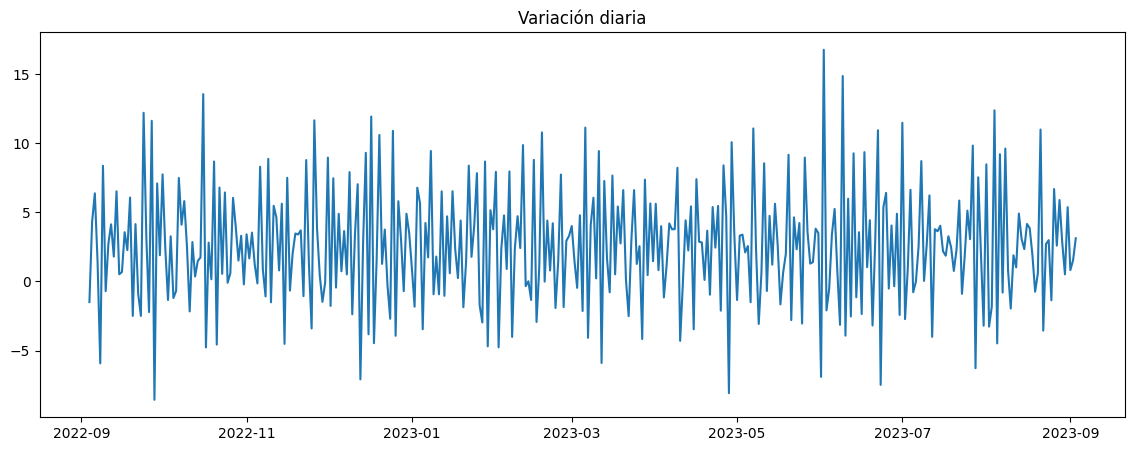

In [20]:
plt.figure(figsize=(14,5))
plt.plot(df_ts["sales"].diff())
plt.title("Variación diaria")
plt.show()

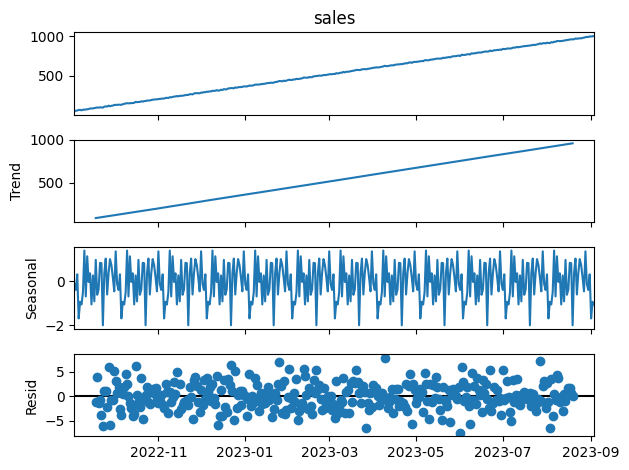

In [21]:
decomposition = seasonal_decompose(df_ts["sales"], model="additive", period=30)
decomposition.plot()
plt.show()

In [22]:
result = adfuller(df_ts["sales"])
print("p-value:", result[1])

p-value: 0.9861899815311065


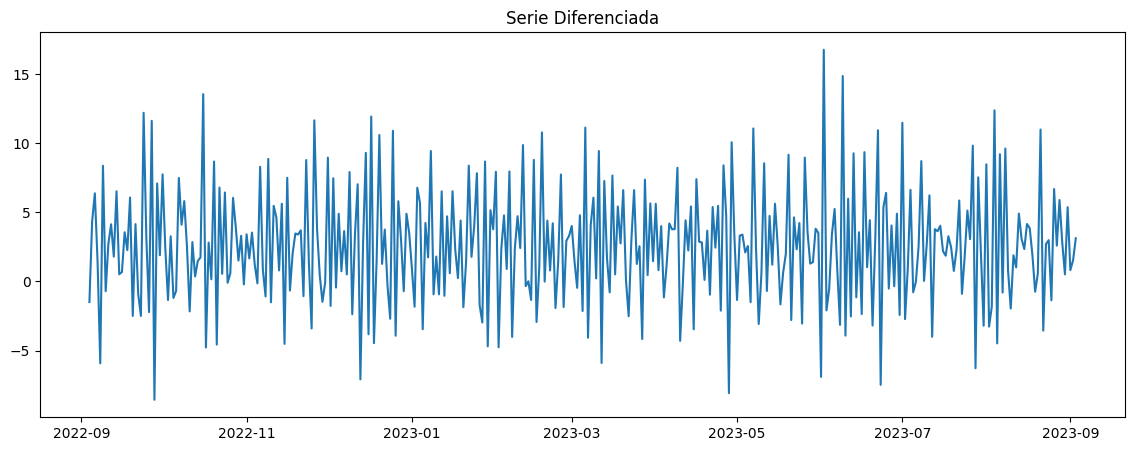

In [23]:
df_diff = df_ts["sales"].diff().dropna()

plt.figure(figsize=(14,5))
plt.plot(df_diff)
plt.title("Serie Diferenciada")
plt.show()

In [24]:
adfuller(df_diff)[1]

np.float64(5.212954111417252e-16)

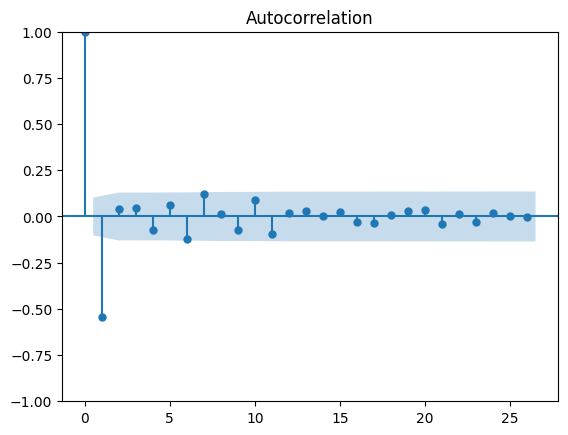

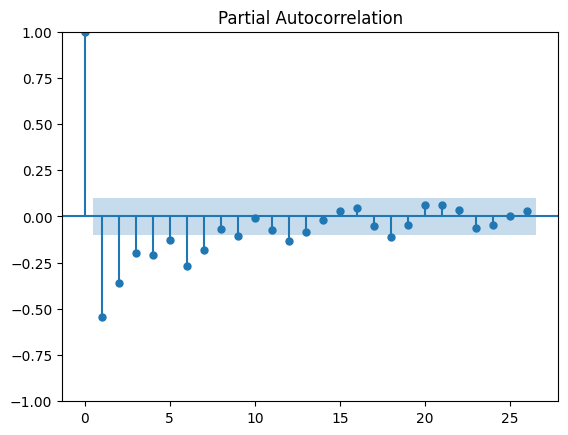

In [25]:
plot_acf(df_diff)
plt.show()

plot_pacf(df_diff)
plt.show()

Tensor: Diario

Tendencia: Creciente

¿Estacionaria?: No inicialmente, sí tras diferenciación

¿Ruido?: Sí, variabilidad natural diaria

<div style="
background: linear-gradient(135deg,#e1f5fe,#f3e5f5);
padding:25px;
border-radius:15px;
text-align:center;
margin:20px auto;
max-width:1000px;
border:1px solid #e0e0e0;
">

<h2 style="color:#0277bd;">
🤖 Entrenamiento del Modelo ARIMA
</h2>

<p style="color:#666;">
Selección automática de parámetros y ajuste del modelo
</p>

</div>

In [26]:
train_size = int(len(df_ts)*0.8)

In [27]:
train = df_ts["sales"][:train_size]
test = df_ts["sales"][train_size:]

In [28]:
auto_model = auto_arima(
    train,
    seasonal=False,
    trace=True,
    suppress_warnings=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.80 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1675.428, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1578.564, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1475.165, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1763.761, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1475.512, Time=0.23 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1475.495, Time=0.19 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1479.028, Time=0.21 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1762.924, Time=0.04 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 1.739 seconds


In [29]:
auto_model.order

(0, 1, 1)

In [30]:
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  292
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -734.582
Date:                Wed, 29 Apr 2026   AIC                           1475.165
Time:                        06:30:04   BIC                           1486.185
Sample:                    09-03-2022   HQIC                          1479.579
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.5984      0.011    243.641      0.000       2.577       2.619
ma.L1         -0.9439      0.021    -44.117      0.000      -0.986      -0.902
sigma2         9.0537      0.817     11.084      0.0

In [31]:
forecast = auto_model.predict(n_periods=12)
forecast

2023-06-22    810.107776
2023-06-23    812.706154
2023-06-24    815.304531
2023-06-25    817.902909
2023-06-26    820.501287
2023-06-27    823.099664
2023-06-28    825.698042
2023-06-29    828.296419
2023-06-30    830.894797
2023-07-01    833.493175
2023-07-02    836.091552
2023-07-03    838.689930
Freq: D, dtype: float64

In [32]:
model = ARIMA(train, order=auto_model.order)

c:\Users\nata1\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\nata1\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\nata1\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [33]:
model_fit = model.fit()

In [34]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  292
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -879.462
Date:                Wed, 29 Apr 2026   AIC                           1762.924
Time:                        06:30:04   BIC                           1770.271
Sample:                    09-03-2022   HQIC                          1765.867
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0758      0.077     -0.981      0.326      -0.227       0.076
sigma2        24.6927      2.048     12.056      0.000      20.679      28.707
Ljung-Box (L1) (Q):                  73.69   Jarque-

<div style="
background: linear-gradient(135deg,#f1f8e9,#fffde7);
padding:25px;
border-radius:15px;
text-align:center;
margin:20px auto;
max-width:1000px;
border:1px solid #e0e0e0;
">

<h2 style="color:#558b2f;">
🔮 Predicción y Evaluación del Modelo
</h2>

<p style="color:#666;">
Comparación entre valores reales y predicciones
</p>

</div>

In [35]:
forecast = model_fit.get_forecast(steps=len(test))

In [36]:
predictions = forecast.predicted_mean

In [37]:
predictions

2023-06-22    805.739749
2023-06-23    805.739749
2023-06-24    805.739749
2023-06-25    805.739749
2023-06-26    805.739749
                 ...    
2023-08-30    805.739749
2023-08-31    805.739749
2023-09-01    805.739749
2023-09-02    805.739749
2023-09-03    805.739749
Freq: D, Name: predicted_mean, Length: 74, dtype: float64

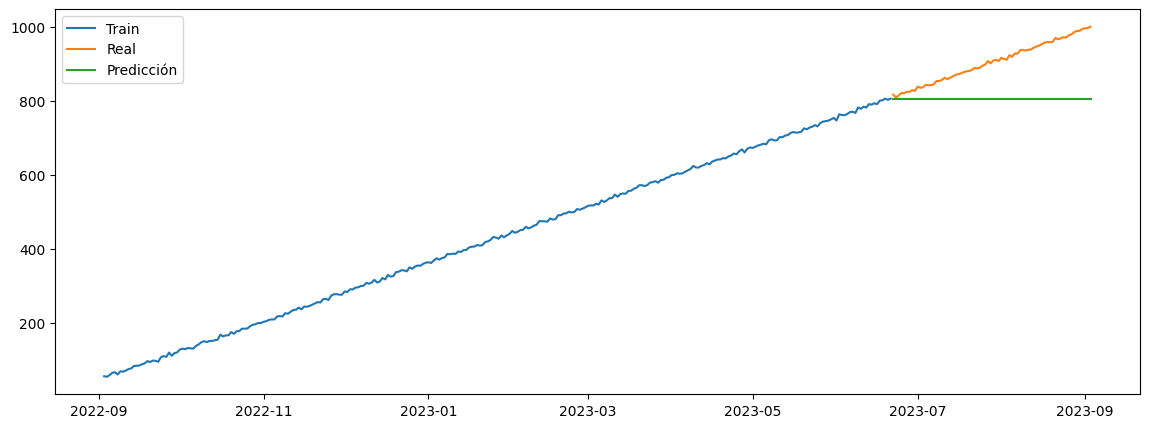

In [38]:
plt.figure(figsize=(14,5))

plt.plot(train, label="Train")
plt.plot(test, label="Real")
plt.plot(test.index, predictions, label="Predicción")

plt.legend()
plt.show()

El modelo ARIMA(0,1,1) seleccionado automáticamente modela el crecimiento promedio de la serie temporal. Debido a que las ventas presentan una tendencia creciente casi lineal y baja variabilidad, el modelo genera predicciones muy similares entre sí, proyectando un crecimiento estabke basado en el comportamiento hist´rico observado. este resultado es esperado y refleja la naturaleza suavizada del modelo ARIMA ante series con tendencia constante.

In [39]:
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = mean_absolute_percentage_error(test, predictions)
r2 = r2_score(test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print(f"MAPE: {mape:.4f}")
print(f"R²: {r2:.4f}")

MAE: 98.86462982803404
RMSE: 113.37754061886254
MAPE: 0.1059
R²: -3.1732


In [40]:
sarima=SARIMAX(train,order=( 0 , 1 , 1 ),seasonal_order=( 1 , 1 , 1 , 7 ))

c:\Users\nata1\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\nata1\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [41]:
sarima_fit =sarima.fit()

In [42]:
print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                  292
Model:             SARIMAX(0, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -723.595
Date:                           Wed, 29 Apr 2026   AIC                           1455.189
Time:                                   06:30:06   BIC                           1469.785
Sample:                               09-03-2022   HQIC                          1461.041
                                    - 06-21-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9426      0.025    -38.109      0.000      -0.991      -0.894
ar.S.L7        0.1025      0.075      1.363

In [43]:
forecast = sarima_fit.get_forecast(steps=len(test))

In [44]:
predictions = forecast.predicted_mean
predictions

2023-06-22     809.636111
2023-06-23     811.270157
2023-06-24     816.386042
2023-06-25     818.798055
2023-06-26     821.576961
                 ...     
2023-08-30     989.263122
2023-08-31     991.267153
2023-09-01     993.357461
2023-09-02     997.987100
2023-09-03    1000.556004
Freq: D, Name: predicted_mean, Length: 74, dtype: float64

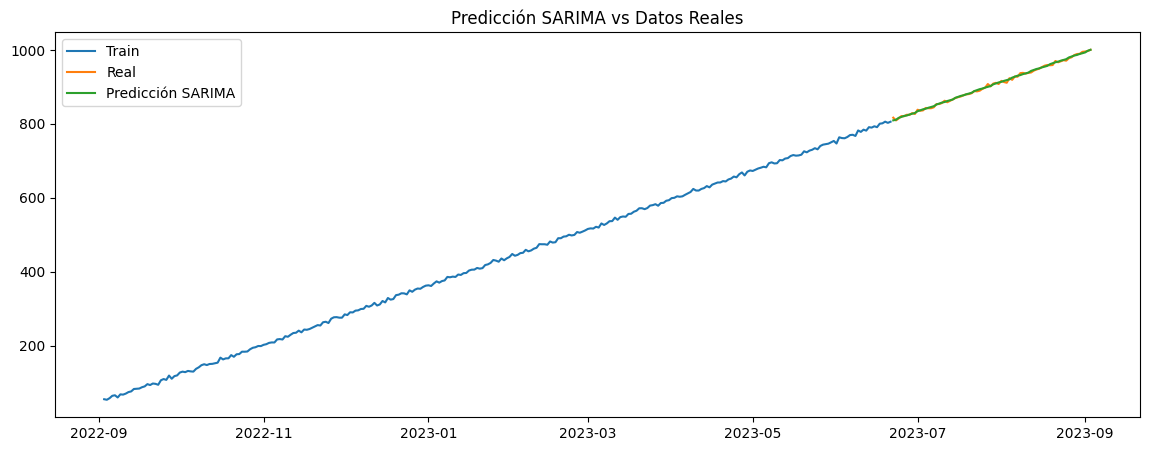

In [45]:
plt.figure(figsize=(14,5))

plt.plot(train, label="Train")
plt.plot(test, label="Real")
plt.plot(test.index, predictions, label="Predicción SARIMA")

plt.title("Predicción SARIMA vs Datos Reales")
plt.legend()
plt.show()

In [46]:
rmse_sarima = np.sqrt(mean_squared_error(test, predictions))
mape_sarima = mean_absolute_percentage_error(test, predictions)
r2_sarima = r2_score(test, predictions)

print(f"SARIMA RMSE: {rmse_sarima:.4f}")
print(f"SARIMA MAPE: {mape_sarima:.4f}")
print(f"SARIMA R²: {r2_sarima:.4f}")

SARIMA RMSE: 2.8202
SARIMA MAPE: 0.0025
SARIMA R²: 0.9974


<div style=" background: linear-gradient(135deg, #f3e5f5, #e8f5e9); padding:30px; border-radius:18px; text-align:center; border:1px solid #e0e0e0; box-shadow:0px 4px 10px rgba(0,0,0,0.08); margin:20px auto; max-width:1000px; "> <h1 style="color:#6A1B9A;"> 📊 Comparación Final: ARIMA vs SARIMA </h1> <h3 style="color:#2E7D32;"> Análisis del comportamiento predictivo </h3> </div>

Se concluye que el modelo SARIMA ofrece un mejor desempeño predictivo que ARIMA para este sistema de predicción de ventas, ya que logra reproducir con mayor precisión la tendencia creciente observada en los datos reales.

El modelo SARIMA permite generar estimaciones más confiables del ritmo de ventas futuras, proporcionando una base sólida para la toma de decisiones estratégicas relacionadas con la planificación del nuevo almacén y la estimación del espacio requerido.

<div style="
background: linear-gradient(135deg,#fce4ec,#e0f7fa);
padding:25px;
border-radius:15px;
text-align:center;
border:1px solid #e0e0e0;
margin:20px auto;
max-width:1000px;
">

<h2 style="color:#ad1457;">
💾 Persistencia del Modelo
</h2>

<p style="color:#666;">
Almacenamiento del modelo entrenado para uso futuro
</p>

</div>

In [47]:
joblib.dump(sarima_fit, "../models/sarima_sales_model.pkl")

['../models/sarima_sales_model.pkl']

<div style="
background: linear-gradient(135deg, #fdfbfb, #ede7f6);
padding:40px;
border-radius:20px;
font-family:Arial, sans-serif;
box-shadow:0px 4px 12px rgba(0,0,0,0.1);
max-width:1350px;
margin:20;
color:#000000;
">

<h2 style="text-align:center; color:#7E57C2;">
📈 Conclusión Final — Sistema de Predicción de Ventas con ARIMA y SARIMA
</h2>

<p style="font-size:16px; line-height:1.7; color:#000000;">
El presente proyecto permitió desarrollar un sistema predictivo basado en 
<strong style="color:#6C9BCF;">Análisis de Series Temporales</strong>,
integrando técnicas estadísticas y modelos de pronóstico para estimar el 
comportamiento futuro de las ventas. Inicialmente se realizó un 
<span style="background-color:#F3E5F5; padding:4px 8px; border-radius:8px;">
Análisis Exploratorio de Datos (EDA)
</span>
con el objetivo de comprender la tendencia temporal, identificar patrones
de crecimiento y evaluar la estructura general de la serie histórica.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
El análisis evidenció una tendencia creciente sostenida en el tiempo,
indicando que la serie no era estacionaria. Por esta razón, fue necesario
aplicar procesos de diferenciación para estabilizar la media y permitir
la correcta aplicación de modelos predictivos.
Posteriormente se utilizó el algoritmo 
<strong style="color:#7E57C2;">Auto ARIMA</strong>,
el cual permitió seleccionar automáticamente el mejor conjunto de parámetros
(p, d, q), obteniendo como resultado un modelo ARIMA(0,1,1).
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
Aunque el modelo ARIMA logró capturar parcialmente la dinámica de la serie,
las predicciones obtenidas tendieron a comportarse de forma constante,
lo que evidenció limitaciones para representar completamente el crecimiento
observado en los datos reales.
Este comportamiento sugirió la existencia de componentes temporales adicionales
no modelados por ARIMA.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
Con el fin de mejorar la capacidad predictiva, se implementó el modelo
<strong style="color:#26A69A;">SARIMA</strong>,
incorporando un 
<span style="background-color:#E3F2FD; padding:4px 8px; border-radius:8px;">
Seasonal Order
</span>
que permitió modelar patrones repetitivos dentro de la serie temporal.
La inclusión del componente estacional permitió que el modelo siguiera con mayor
precisión la tendencia creciente, generando predicciones más realistas y alineadas
con los valores observados.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
La comparación entre ambos enfoques demostró que la incorporación de estacionalidad
mejora significativamente la capacidad de generalización del sistema predictivo.
El modelo SARIMA presentó un ajuste visual superior y una mayor coherencia temporal,
confirmando que la serie posee comportamientos periódicos relevantes para el pronóstico.
</p>

<ul style="font-size:16px; line-height:1.7;">
<li>✅ <strong>Preparación de datos:</strong> identificación de tendencia y estacionariedad.</li>
<li>✅ <strong>Modelado ARIMA:</strong> selección automática de parámetros óptimos.</li>
<li>✅ <strong>Modelado SARIMA:</strong> incorporación de componentes estacionales.</li>
<li>✅ <strong>Comparación de modelos:</strong> validación del mejor enfoque predictivo.</li>
</ul>

<p style="font-size:16px; line-height:1.7; color:#000000;">
En conclusión, el proyecto evidencia cómo el análisis de series temporales permite
transformar datos históricos en herramientas estratégicas de planificación.
La implementación progresiva desde ARIMA hacia SARIMA demostró que comprender la
estructura temporal de los datos es fundamental para obtener predicciones confiables,
permitiendo apoyar decisiones empresariales relacionadas con crecimiento,
planificación logística y proyección futura de la demanda.
</p>

</div>